# 실습 - 허리케인 피해 지역 구분하기


## 개요
  - 허리케인이 지나간 위치의 위성 이미지를 보고, 피해 여부를 판단하는 모델을 만들어 봅시다.

## 목표
  - validation dataset 에 대해 95% 이상의 정확도를 가지는 것이 목표입니다.

In [1]:
import urllib
import zipfile

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
def download_and_extract_data():
    url = 'https://storage.googleapis.com/download.tensorflow.org/data/certificate/satellitehurricaneimages.zip'
    urllib.request.urlretrieve(url, 'satellitehurricaneimages.zip')
    with zipfile.ZipFile('satellitehurricaneimages.zip', 'r') as zip_ref:
        zip_ref.extractall()

download_and_extract_data()

# 1 & 2. 데이터 준비 & 이미지 전처리

  - 다운로드 받은 데이터를 읽어서 준비합니다.
  - 전처리를 수행합니다.

In [3]:
IMG_SIZE = 128
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
      rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        'train/', 
    target_size= (IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
        'validation/',
    target_size= (IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
        class_mode='binary')

Found 10000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


# 3. 모델 정의

  - 모델 모양을 정의합니다.
  - Input, Output 모양을 유의하세요.

In [5]:
model = tf.keras.models.Sequential([
    # CNN layers
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    # Dense layers
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

c:\Users\User\miniconda3\envs\dl_312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 4. 모델 컴파일

  - 학습 방법을 정의하세요
  - loss, optimizer, metrics 를 올바르게 지정하면 충분합니다.

In [6]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5. 모델 학습

  - 학습을 위한 epoch, batch_size 등을 설정하세요.
  - 이 외에 사용하고 싶은 기법들은 자유롭게 도입하셔도 됩니다.

In [8]:
# model.fit(
#         train_generator,
#         validation_data=validation_generator,
#         epochs=5,
#         batch_size=BATCH_SIZE
# )


# Add callbacks for better training
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
]

model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,  
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 317ms/step - accuracy: 0.8139 - loss: 0.4423 - val_accuracy: 0.9075 - val_loss: 0.2263 - learning_rate: 0.0010
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 315ms/step - accuracy: 0.9282 - loss: 0.1825 - val_accuracy: 0.9430 - val_loss: 0.1352 - learning_rate: 0.0010
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 316ms/step - accuracy: 0.9523 - loss: 0.1205 - val_accuracy: 0.9625 - val_loss: 0.1025 - learning_rate: 0.0010
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 320ms/step - accuracy: 0.9630 - loss: 0.1047 - val_accuracy: 0.9635 - val_loss: 0.1102 - learning_rate: 0.0010
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 55s 353ms/step - accuracy: 0.9677 - loss: 0.0894 - val_accuracy: 0.9645 - val_loss: 0.1019 - learning_rate: 0.0010
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 66s 418ms/step - accuracy: 0.9690 - loss: 0.0778 - val_accuracy: 0.9550 - val_loss: 0.1146 - learning_rate: 0.0010
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 73s 462ms/step - accuracy: 0.9

# Appendix

- 이미지를 View 합니다.
- model 로 predict 를 합니다.

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Take one batch of images and labels
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    directory='validation/',
    image_size= (IMG_SIZE,IMG_SIZE)
    , batch_size=BATCH_SIZE)

Found 2000 files belonging to 2 classes.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


C:\Users\User\AppData\Local\Temp\ipykernel_17392\3136975117.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted_label = int(predictions.round())


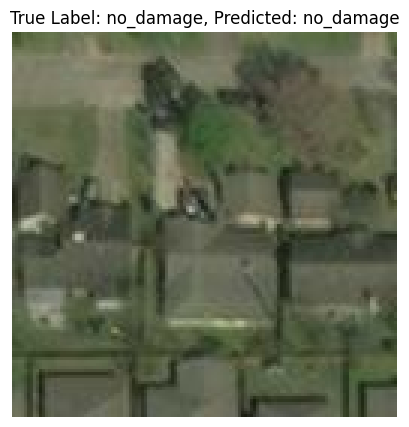

In [12]:
images, labels = next(iter(val_ds.shuffle(buffer_size=10000)))

data_index = 0

selected_image = images[data_index].numpy().astype("uint8")
selected_label = labels[data_index].numpy()

image_to_predict = np.expand_dims(selected_image/255, axis=0)

# Make a prediction
predictions = model.predict(image_to_predict)
predicted_label = int(predictions.round())

plt.figure(figsize=(5,5))
plt.imshow(selected_image)
class_names = val_ds.class_names
plt.title(f"True Label: {class_names[selected_label]}, Predicted: {class_names[predicted_label]}")
plt.axis("off")
plt.show()

# Transfer Learning

- transfer learning 을 이용해서도 풀어봅시다.

In [ ]:
# 자유롭게 작성하세요.